# UE04 - Parameterschätzung und Konfidenzintervalle (KIs)

Um das Wissen zur Parameterschätzung vertiefen zu können, beschäftigt sich Übung UE04 noch einmal mit dem Schätzen von Parametern einer Verteilung.
Erweitert wird diese Übung um das Konzept der Konfidenzintervalle (Skriptum S. 26ff) und das Ermitteln der Stichprobengröße in Abhängigkeit zur Sicherheit und Genauigkeit der Schätzung.

So soll ein Einblick in die Datenanalyse im Allgemeinen, sowie die Konfidenzintervalle und die Stichprobenplanung im Speziellen, möglich sein.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats



## UE04.a)
Einlesen der Daten einer repräsentativen Studie zu den Essgewohnheiten der österreichischen Bevölkerung.

<ol>
    <li>Platziere die Datei <tt>eating_habits.npy</tt> aus dem Moodlekurs im Ordner <tt>data/</tt>. Lade anschließend <tt>data/eating_habits.npy</tt> in die Variable <tt>eating_habits</tt>.
        <br>
        <strong>Vorsicht</strong>: Die Daten in <tt>eating_habits.npy</tt> wurden als <a href="https://docs.python.org/3/tutorial/datastructures.html#dictionaries">Dictionary</a> abgelegt. Dictionaries können über den <a href="https://numpy.org/doc/stable/reference/generated/numpy.load.html">load()</a>-Befehl von NumPy geladen werden.
        Allerdings muss dafür der Parameter <tt>allow_pickle=True</tt> gesetzt werden.
        <br>
        Da der <tt>eating_habits = load(...)</tt>-Befehl das geladene Dictionary in einem Container (Array) ablegt, erleichtert ein Aufruf der Methode <tt>eating_habits = eating_habits.item()</tt> den Zugriff auf die Daten im Dictionary.
    </li>
    <li>Wir nehmen an, dass die Daten in der Datei <tt>eating_habits.npy</tt> ein kleiner Teil der Resultate einer Langzeitstudie zu den Essensgewohnheiten der österreichischen Bevölkerung widerspiegeln.<br>
        In einem Zeitraum von 10 Jahren wurde den Proband:innen folgende Frage gestellt: <strong>"Sehen Sie sich als Vegetarier:in?"</strong><br>
        Antworten von Personen, die ihre Essgewohnheiten mit vegetarisch beschreiben würden, sind als <strong>'V'</strong> kodiert. Wurde die Frage verneint, ist dies als <strong>'N'</strong> abgelegt.<br>
        Die Rückmeldungen sind nach Jahren gruppiert.
    </li>
    <li>Drei kleine Einstiegsübungen zum Umgang mit Dictionaries und NumPy-Arrays in Python:
        <ul>
            <li>Gib formattiert aus, welche Jahre in <tt>eating_habits</tt> abgelegt sind.</li>
            <li>Gib die Anzahl der Befragten, die pro Jahr aufgezeichnet wurden, formattiert aus.</li>
            <li>Zähle die absolute Anzahl jener Personen, die ihre Essgewohnheiten als vegetarisch beschreiben, pro Jahr und gib die Ergebnisse formattiert aus.</li>
        </ul>
    </li>
    <li>Welcher Verteilung folgen die Zufallsvariablen, die für die einzelnen Jahre aufgezeichnet wurden?<br>
        Beantworte außerdem, welche(r) Parameter für diese Verteilung geschätzt werden kann/können.</li>
</ol>

In [4]:
# 1. Daten laden
eating_habits = np.load('data/eating_habits.npy', allow_pickle=True).item()

# 3. Einstiegsübungen
print("--- Registrierte Jahre ---")
jahre = sorted(list(eating_habits.keys()))
print(f"Jahre im Datensatz: {jahre}\n")

print("--- Befragte pro Jahr ---")
for jahr in jahre:
    n_jahr = len(eating_habits[jahr])
    print(f"Jahr {jahr}: {n_jahr} Befragte")
print()

print("--- Vegetarier:innen absolute Anzahl pro Jahr ---")
for jahr in jahre:
    veggies = np.sum(eating_habits[jahr] == 'V')
    print(f"Jahr {jahr}: {veggies} Personen identifizieren sich als vegetarisch")

--- Registrierte Jahre ---
Jahre im Datensatz: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

--- Befragte pro Jahr ---
Jahr 2015: 11927 Befragte
Jahr 2016: 11486 Befragte
Jahr 2017: 10277 Befragte
Jahr 2018: 12099 Befragte
Jahr 2019: 8057 Befragte
Jahr 2020: 11975 Befragte
Jahr 2021: 8847 Befragte
Jahr 2022: 7867 Befragte
Jahr 2023: 11069 Befragte
Jahr 2024: 11781 Befragte

--- Vegetarier:innen absolute Anzahl pro Jahr ---
Jahr 2015: 773 Personen identifizieren sich als vegetarisch
Jahr 2016: 1246 Personen identifizieren sich als vegetarisch
Jahr 2017: 1574 Personen identifizieren sich als vegetarisch
Jahr 2018: 1943 Personen identifizieren sich als vegetarisch
Jahr 2019: 1885 Personen identifizieren sich als vegetarisch
Jahr 2020: 2614 Personen identifizieren sich als vegetarisch
Jahr 2021: 2637 Personen identifizieren sich als vegetarisch
Jahr 2022: 1815 Personen identifizieren sich als vegetarisch
Jahr 2023: 3025 Personen identifizieren sich als vegetarisch
Jahr 2024

Theoretische Fragen (Punkt 4)Verteilung: Da es sich um eine Ja/Nein-Frage ("Sehen Sie sich als Vegetarier:in?") handelt, folgt jede einzelne Antwort einer Bernoulli-Verteilung. Wenn wir die Anzahl der "V"-Antworten pro Jahr betrachten, folgt diese einer Binomialverteilung $B(n, p)$.Parameter: Der zu schätzende Parameter ist die Erfolgswahrscheinlichkeit $p$ (der wahre Anteil der Vegetarier:innen in der Bevölkerung).


## UE04.b)
Analyse der Daten einer repräsentativen Studie zu den Essgewohnheiten der österreichischen Bevölkerung für das erste Jahr der Aufzeichnung.

<ol>
    <li>Schätze den Anteil der Vegetarier:innen der österreichischen Bevölkerung für das erste Jahr der Aufzeichnung. Limitiere dazu die vorliegende Stichprobe auf eine Stichprobengröße $n=100$. Berechne dann das Konfidenzintervall mit 95% Sicherheit für den wahren Anteil der Vegetarier:innen in der österreichischen Bevölkerung.<br>
        Gib den geschätzten Anteil sowie die obere und untere Grenze des Konfidenzintervalls formattiert aus.<br>
        Reicht eine Stichprobengröße von $n=100$ aus, um eine Aussage über den wahren Anteil der Vegetarier:innen an der österreichischen Bevölkerung für das erste Jahr der Aufzeichnung treffen zu können?
    </li>
    <li>
        Erstelle einen Lineplot zur Darstellung des geschätzten Anteils der Vegetarier:innen sowie das 95% KI über $n$ für das erste Jahr der Aufzeichnung.
        <ul>
            <li>Hierzu ist es notwendig, den Anteil der Vegetarier:innen sowie das 95% KI bei sich verändernder Stichprobengröße $n$ zu berechnen.</li>
            <li>Beginne bei $n=100$ und erhöhe $n$ in beliebiger Schrittweite ($100$ bietet sich bspw. an) bis zum Maximum der Stichprobengröße.</li>
            <li>Zeichne den Lineplot inkl. Achsenbeschriftung, Titel und Legende.</li>
            <li>Was kann dieser Grafik entnommen werden? Kann eine Aussage zur optimalen Stichprobengröße (Trade-off Zeitaufwand und Genauigkeit der Schätzung in Bezug auf die Gesamtbevölkerung) anhand dieses Diagramms getroffen werden?</li>
        </ul>
    </li>
    <li>Berechne, wie groß die Stichprobe zu wählen ist, um den wahren Anteil der Vegetarier:innen der österreichischen Bevölkerung des erste Jahres der Aufzeichnung mit 99%iger Sicherheit auf ±1% genau zu schätzen. <strong>Hint: Formel umstellen!</strong></li>
</ol>

--- Schätzung für n = 100 (Jahr 2015) ---
Geschätzter Anteil: 8.00%
95% KI: [2.68%, 13.32%]


<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Alex\AppData\Local\Temp\ipykernel_10324\1545850336.py:44: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(n_values, p_hats, label='Geschätzter Anteil $\hat{p}$', color='blue', lw=2)


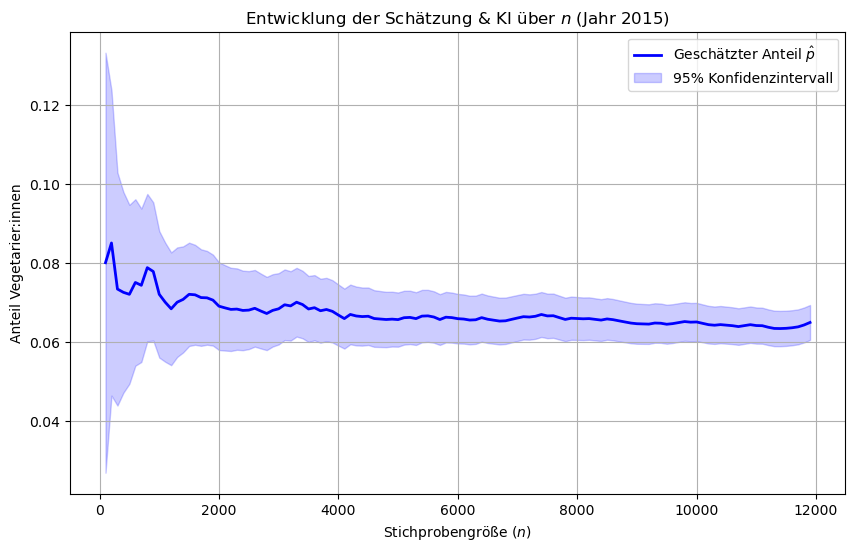

--- Erforderliche Stichprobengröße ---
Benötigtes n: 4022


In [5]:
# Erstes Jahr extrahieren
erstes_jahr = jahre[0]
daten_jahr1 = eating_habits[erstes_jahr]

# ==========================================
# 1. Schätzung für n = 100
# ==========================================
n_100 = 100
stichprobe_100 = daten_jahr1[:n_100]
p_hat_100 = np.sum(stichprobe_100 == 'V') / n_100

alpha_95 = 0.05
z_95 = stats.norm.ppf(1 - alpha_95/2)
se_100 = np.sqrt((p_hat_100 * (1 - p_hat_100)) / n_100)

ki_unten_100 = p_hat_100 - z_95 * se_100
ki_oben_100 = p_hat_100 + z_95 * se_100

print(f"--- Schätzung für n = 100 (Jahr {erstes_jahr}) ---")
print(f"Geschätzter Anteil: {p_hat_100:.2%}")
print(f"95% KI: [{ki_unten_100:.2%}, {ki_oben_100:.2%}]")
# Interpretation: n=100 ist meist zu ungenau, da die KI-Spanne sehr breit ist.

# ==========================================
# 2. Lineplot über sich veränderndes n
# ==========================================
n_values = np.arange(100, len(daten_jahr1) + 1, 100)
p_hats = []
ki_intervals = []

for n in n_values:
    sub_sample = daten_jahr1[:n]
    p_h = np.sum(sub_sample == 'V') / n
    se = np.sqrt((p_h * (1 - p_h)) / n)
    margin = z_95 * se
    
    p_hats.append(p_h)
    ki_intervals.append(margin)

p_hats = np.array(p_hats)
ki_intervals = np.array(ki_intervals)

plt.figure(figsize=(10, 6))
plt.plot(n_values, p_hats, label='Geschätzter Anteil $\hat{p}$', color='blue', lw=2)
plt.fill_between(n_values, p_hats - ki_intervals, p_hats + ki_intervals, 
                 color='blue', alpha=0.2, label='95% Konfidenzintervall')
plt.xlabel('Stichprobengröße ($n$)')
plt.ylabel('Anteil Vegetarier:innen')
plt.title(f'Entwicklung der Schätzung & KI über $n$ (Jahr {erstes_jahr})')
plt.legend()
plt.grid(True)
plt.show()

# Interpretation: Mit steigendem n wird das KI enger (Präzision steigt). 
# Der Trade-off flacht ab einem gewissen Punkt ab (Gesetz des abnehmenden Grenznutzens).

# ==========================================
# 3. Stichprobenberechnung für 99% Sicherheit und ±1% Genauigkeit
# ==========================================
alpha_99 = 0.01
z_99 = stats.norm.ppf(1 - alpha_99/2)
E = 0.01  # ±1%
# Wir nutzen den eben geschätzten Anteil des Gesamtdatensatzes des ersten Jahres als Best-Guess
p_pilot = np.sum(daten_jahr1 == 'V') / len(daten_jahr1)

n_erforderlich = (z_99**2 * p_pilot * (1 - p_pilot)) / (E**2)
print(f"--- Erforderliche Stichprobengröße ---")
print(f"Benötigtes n: {int(np.ceil(n_erforderlich))}")


## UE04.c)
Analyse der Daten einer repräsentativen Studie zu den Essgewohnheiten der österreichischen Bevölkerung im 10-Jahresverlauf.

<ol>
<li>Berechne den Anteil der Vegetarier:innen und das 99% KI für alle Stichproben der aufgezeichneten Jahre und stelle diese Information in einer geeigneten Grafik dar.</li>
<ul>
    <li>Was kann über die jährliche Entwicklung des Anteils der Vegetarier:innen an der österr. Bevölkerung auf Basis dieser Grafik gesagt werden?</li>
    <li>In welchen Jahren ist ein klarer Anstieg des Anteils der Vegetarier:innen an der österr. Bevölkerung zu erkennen?</li>
    <li>Fällt der Anteil der Vegetarier:innen im Jahresverlauf auch wieder?</li>
</ul>

<li>Wiederhole UE04.c) 1. mit eingeschränkter Stichprobengröße $n=250$ und vergleiche die Aussagequalität der Studie bei unters Unterschiede in der Aussagequalität der Studie bei kleiner Stichprobengröße feststellbar sind.</li>
</ol>


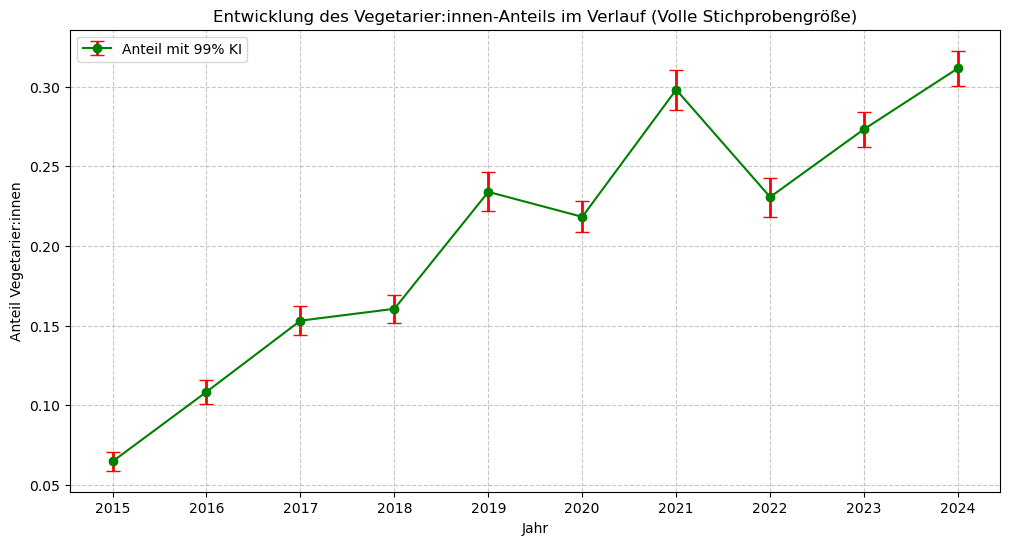

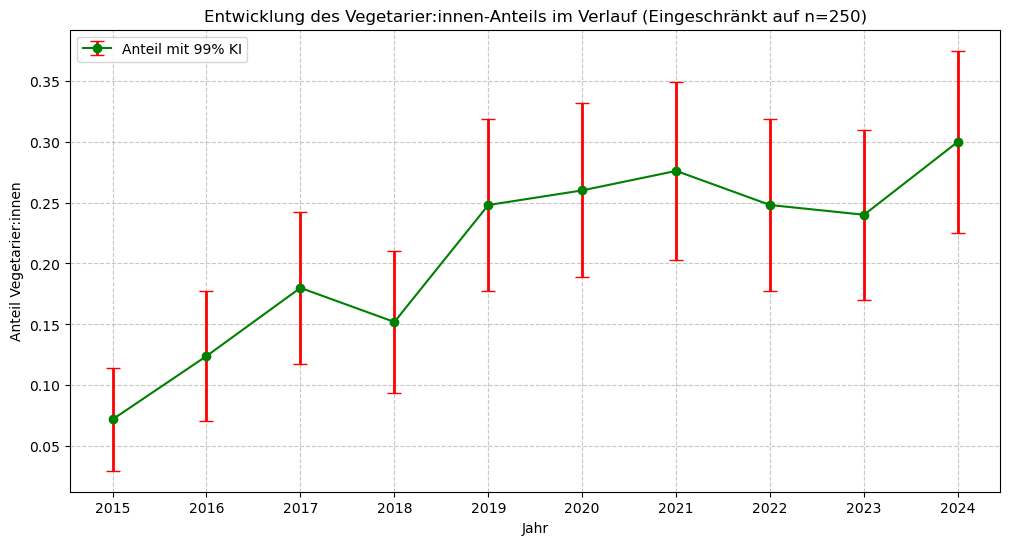

In [6]:
def plot_jahresverlauf(max_n=None, titel_erweiterung=""):
    jahre_liste = []
    anteile = []
    fehler_unten = []
    fehler_oben = []
    
    alpha_99 = 0.01
    z_99 = stats.norm.ppf(1 - alpha_99/2)
    
    for jahr in jahre:
        daten = eating_habits[jahr]
        if max_n is not None:
            daten = daten[:max_n]
            
        n = len(daten)
        p_h = np.sum(daten == 'V') / n
        se = np.sqrt((p_h * (1 - p_h)) / n)
        margin = z_99 * se
        
        jahre_liste.append(str(jahr))
        anteile.append(p_h)
        fehler_unten.append(p_h - margin)
        fehler_oben.append(p_h + margin)
        
    plt.figure(figsize=(12, 6))
    # Errorbars eignen sich hervorragend für den Vergleich von KIs über Zeitreihen
    plt.errorbar(jahre_liste, anteile, yerr=[np.array(anteile)-np.array(fehler_unten), np.array(fehler_oben)-np.array(anteile)], 
                 fmt='-o', color='green', ecolor='red', elinewidth=2, capsize=5, label='Anteil mit 99% KI')
    plt.xlabel('Jahr')
    plt.ylabel('Anteil Vegetarier:innen')
    plt.title(f'Entwicklung des Vegetarier:innen-Anteils im Verlauf {titel_erweiterung}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# 1. Vollständige Stichproben visualisieren
plot_jahresverlauf(titel_erweiterung="(Volle Stichprobengröße)")

# 2. Eingeschränkte Stichprobengröße n = 250
plot_jahresverlauf(max_n=250, titel_erweiterung="(Eingeschränkt auf n=250)")